<a href="https://colab.research.google.com/github/amit-sahu-a11y/ML_projects_for_practice/blob/main/loan_interest_rate_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Interest Rate Prediction (End-to-End Pipeline)**


## Problem Statement

Given a set of applicant and loan-related attributes such as age, employment history, credit score, income, loan amount, loan term, and loan type, the goal is to predict the interest rate offered to a loan applicant.

This is a **supervised machine learning regression problem** where the target variable is:

**Target Variable:** `interest_rate`

## Project Objectives

The key objectives of this project are:

1. Perform exploratory data analysis (EDA) to understand the dataset.
2. Identify and handle data quality issues such as missing values and invalid records.
3. Preprocess the data for machine learning.
4. Build and evaluate multiple regression models.
5. Identify the most influential factors affecting interest rate assignment.
6. Generate business insights and recommendations based on the model results.


Let's start the work!!


---

##  Importing Required Libraries

In [1115]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##  Loading the Dataset

The first step is to load the dataset and verify that it has been imported correctly. This includes inspecting the first few records and understanding the overall structure of the data.

In [1116]:
# Load Dataset
df = pd.read_csv("/content/loan_applications.csv")

# Display first five rows
df.head()

,application_id,applicant_age,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
0,APP00001,24,3,Personal,676.0,10000.0,166999,120.0,14.42
1,APP00002,45,25,Personal,523.0,86595.0,459717,84.0,14.96
2,APP00003,23,2,Personal,573.0,NaN,355985,36.0,13.18
3,APP00004,39,17,Education,785.0,98794.0,186615,NaN,10.66
4,APP00005,43,22,Home,658.0,103832.0,18995,36.0,14.58


---

# **1. Data Understanding**

## Initial Dataset Inspection

Before performing any analysis, it is important to understand the dataset structure, including the number of observations, feature types, missing values, and overall data quality.

In [1117]:
# Dataset Shape
print(f"Dataset Shape: {df.shape}\n")

# Data Types
df.info()

Dataset Shape: (1400, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   application_id    1400 non-null   object 
 1   applicant_age     1400 non-null   int64  
 2   years_employed    1400 non-null   int64  
 3   loan_type         1400 non-null   object 
 4   credit_score      1330 non-null   float64
 5   annual_income     1331 non-null   float64
 6   loan_amount       1400 non-null   int64  
 7   loan_term_months  1330 non-null   float64
 8   interest_rate     1400 non-null   float64
dtypes: float64(4), int64(3), object(2)
memory usage: 98.6+ KB


In [1118]:
df.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
count,1400.000000,1400.000000,1330.000000,1331.000000,1400.000000,1330.000000,1400.000000
mean,40.142857,19.915000,649.053383,93208.605560,253620.917143,54.875188,12.049743
std,12.130498,12.228667,80.873417,41449.840759,142491.631417,34.387397,4.337037
min,20.000000,-5.000000,367.000000,-999.000000,5878.000000,12.000000,0.050000
25%,29.000000,10.000000,598.000000,60263.500000,131499.000000,24.000000,10.280000
50%,40.500000,21.000000,648.000000,94285.000000,251568.000000,48.000000,11.875000
75%,50.000000,30.000000,700.750000,125224.500000,375778.250000,84.000000,13.490000
max,61.000000,40.000000,999.000000,182507.000000,499335.000000,120.000000,50.000000


In [1119]:
# Investigate negative employment duration
df[df["years_employed"] < 0]

,application_id,applicant_age,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
231,APP00232,32,-5,Home,677.0,36989.0,492340,36.0,11.91
618,APP00619,42,-5,Business,706.0,85457.0,334889,48.0,15.29
703,APP00704,59,-5,Personal,631.0,140875.0,230359,48.0,8.63
783,APP00784,51,-5,Home,753.0,140349.0,190681,24.0,9.76
1169,APP01170,28,-5,Auto,739.0,10000.0,233243,24.0,12.63
1196,APP01197,28,-5,Home,794.0,29994.0,128184,12.0,6.78
1279,APP01280,23,-5,Education,546.0,68907.0,463601,60.0,15.58
1362,APP01363,59,-5,Personal,612.0,107278.0,137485,NaN,11.30


In [1120]:
# Investigate unusual credit scores
df[df["credit_score"] > 850]

,application_id,applicant_age,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
75,APP00076,36,17,Personal,900.0,70053.0,101380,84.0,12.36
643,APP00644,28,9,Personal,900.0,47007.0,252111,24.0,12.04
751,APP00752,37,20,Personal,999.0,80249.0,459661,48.0,9.74
998,APP00999,35,16,Home,999.0,85789.0,491162,48.0,15.11
1084,APP01085,48,30,Home,999.0,107616.0,179907,84.0,9.44
1368,APP01369,37,17,Business,900.0,77803.0,100371,84.0,16.99


In [1121]:
#checking missing values.
df.isnull().sum()

,0
application_id,0
applicant_age,0
years_employed,0
loan_type,0
credit_score,70
annual_income,69
loan_amount,0
loan_term_months,70
interest_rate,0


In [1122]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [1123]:
#checking for duplicates in application_id column
df['application_id'].duplicated().sum()

np.int64(0)

## Initial Inspection Findings

The dataset contains **1,400 loan application records** and **9 features**, including applicant demographics, employment information, financial attributes, loan characteristics, and the target variable (`interest_rate`).

### Dataset Structure

The dataset consists of:

- 3 integer features
- 4 numerical (float) features
- 2 categorical features

The target variable for this regression problem is:

- **interest_rate**

### Missing Value Assessment

The initial inspection identified missing values in three columns:

| Feature | Missing Values |
|----------|----------:|
| credit_score | 70 |
| annual_income | 69 |
| loan_term_months | 70 |

All remaining features contain complete records with no missing values.

The proportion of missing data is relatively small compared to the total dataset size, making imputation a suitable strategy during preprocessing.

### Descriptive Statistics Overview

The numerical features appear reasonable overall; however, several observations indicate potential data quality issues that require further investigation.

### Potential Data Quality Issues

#### 1. Invalid Employment Duration

The minimum value for `years_employed` is **-5 years**.

Since employment duration cannot be negative, these records are likely the result of data entry errors or invalid observations.

#### 2. Invalid Income Values

The minimum value for `annual_income` is **-999 USD**.

Negative income values are not realistic in the context of annual gross income and may represent erroneous or placeholder values.

#### 3. Suspicious Credit Scores

The maximum value for `credit_score` is **999**.

This unusually high value may indicate a data quality issue and should be investigated before model development.

#### 4. Interest Rate Extremes

The target variable (`interest_rate`) ranges from **0.05%** to **50.00%**.

These extreme values may represent legitimate observations or potential outliers. Additional analysis is required before deciding whether any treatment is necessary.

### Preliminary Conclusion

The initial inspection confirms the presence of:

- Missing values
- Potential data entry errors
- Suspicious numerical values
- Possible outliers

Before model development, a detailed data quality assessment will be performed to validate these observations and determine the most appropriate preprocessing strategy.


## 1.2 Target Variable Analysis

Understanding the distribution of the target variable is an essential step in regression modeling. This analysis helps identify skewness, outliers, and unusual patterns that may affect model performance.

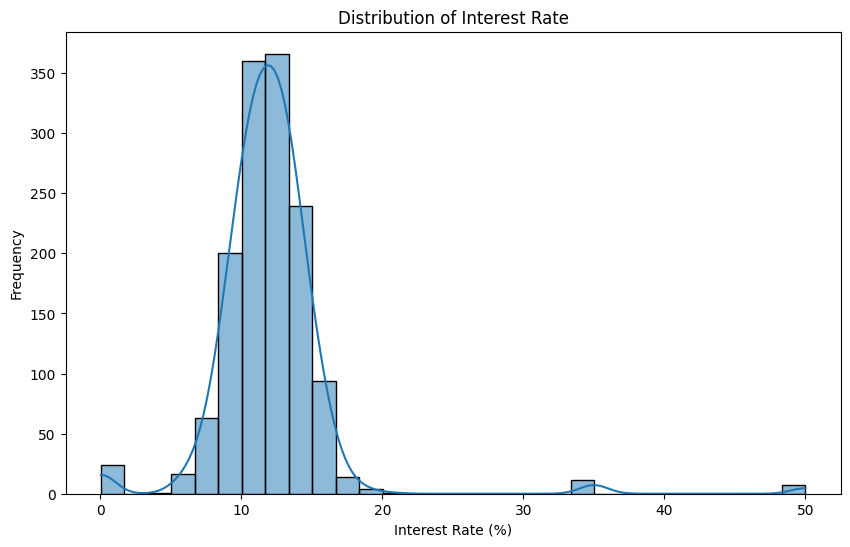

In [1124]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='interest_rate',
    bins=30,
    kde=True,

)

plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')

plt.show()

<Axes: xlabel='annual_income', ylabel='interest_rate'>

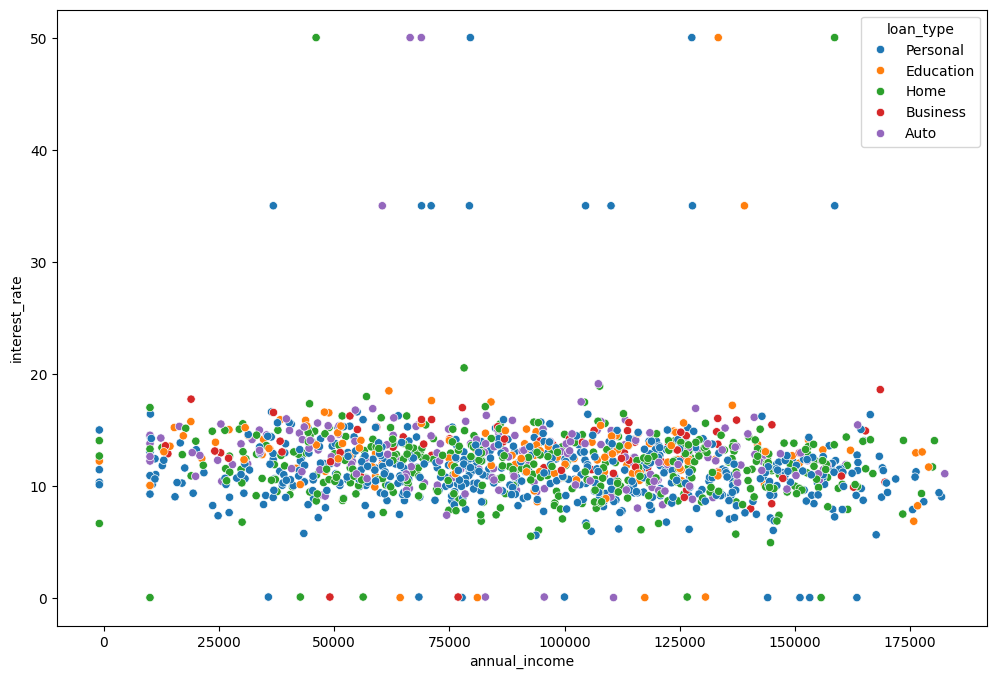

In [1125]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='annual_income',y='interest_rate',data= df,hue='loan_type')

## 1.3 Loan Type Distribution

Understanding the distribution of loan types helps identify whether the dataset is balanced across different loan categories.

Significant imbalance may affect model learning and should be considered during interpretation of results.

In [1126]:
loan_type_counts = df['loan_type'].value_counts()

loan_type_counts

,count
loan_type,
Personal,569
Home,414
Auto,205
Education,138
Business,74


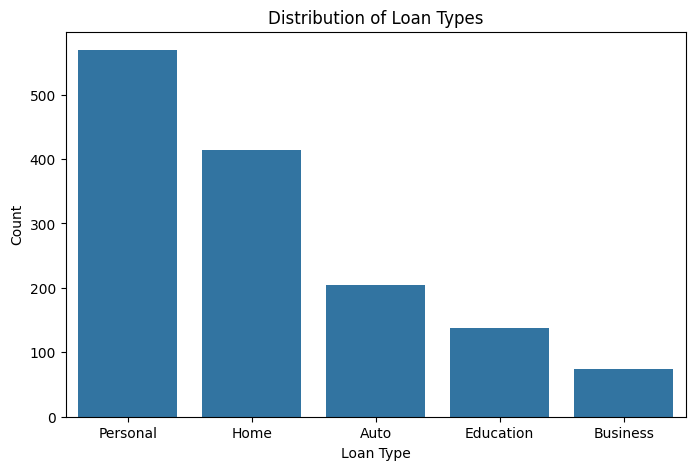

In [1127]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='loan_type',
    order=df['loan_type'].value_counts().index
)

plt.title('Distribution of Loan Types')
plt.xlabel('Loan Type')
plt.ylabel('Count')

# plt.xticks(rotation=45)

plt.show()

#  2. Data Cleaning and Preprocessing

The initial data inspection revealed several data quality issues, including missing values and potentially invalid observations.

The preprocessing phase aims to improve data quality while preserving as much information as possible for model training.



In [1128]:
df['loan_income_ratio'] = df['loan_amount'] / df['annual_income']
df['credit_income'] = df['credit_score'] * df['annual_income']
df['credit_employment'] = df['credit_score'] * df['years_employed']

In [1129]:
df.shape

(1400, 12)

In [1130]:
df_clean = df.copy()

In [1131]:
df_clean.shape

(1400, 12)

### Removing Impossible Values

In [1132]:
# Replace invalid employment duration with NaN
df_clean.loc[df_clean['years_employed'] < 0, 'years_employed'] = np.nan

# Replace invalid annual income with NaN
df_clean.loc[df_clean['annual_income'] < 0, 'annual_income'] = np.nan

df_clean.loc[
    (df_clean['credit_score'] < 300) |
    (df_clean['credit_score'] > 850),
    'credit_score'
] = np.nan

In [1133]:
df_clean.isnull().sum()

,0
application_id,0
applicant_age,0
years_employed,8
loan_type,0
credit_score,76
annual_income,77
loan_amount,0
loan_term_months,70
interest_rate,0
loan_income_ratio,69


In [1134]:
#Irrelevant Column for our Model
df_clean = df_clean.drop(columns=['application_id'])

## Target Outliers Detection and clipping

In [1135]:
Q1 = df_clean['interest_rate'].quantile(0.25)
Q3 = df_clean['interest_rate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df['interest_rate'] >= lower) &
    (df['interest_rate'] <= upper)
]

print(df.shape)
print(df_clean.shape)

(1400, 12)
(1352, 12)


<Axes: ylabel='interest_rate'>

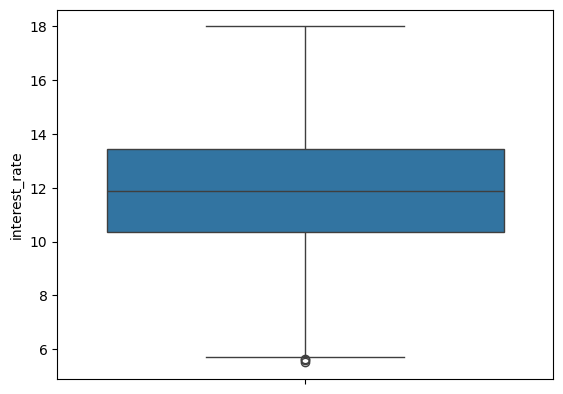

In [1136]:
#Verifying Outliers removal
sns.boxplot(data= df_clean['interest_rate'])

# **3. Exploratory Data Analysis**

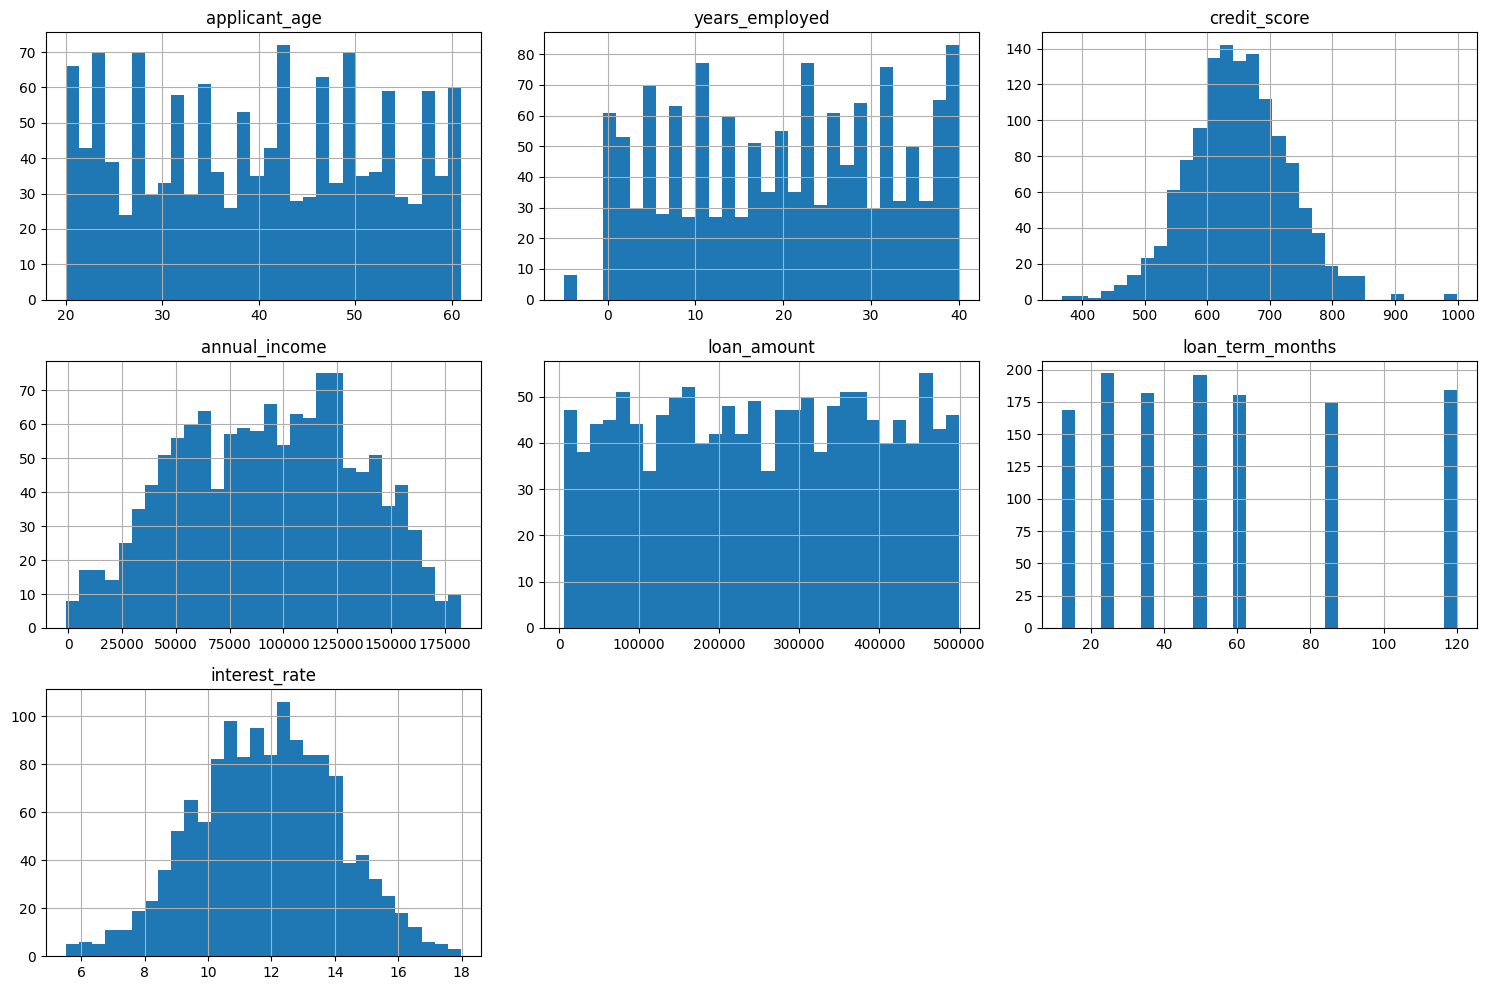

In [1137]:
num_cols = [
    'applicant_age',
    'years_employed',
    'credit_score',
    'annual_income',
    'loan_amount',
    'loan_term_months',
    'interest_rate'
]

df_clean[num_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

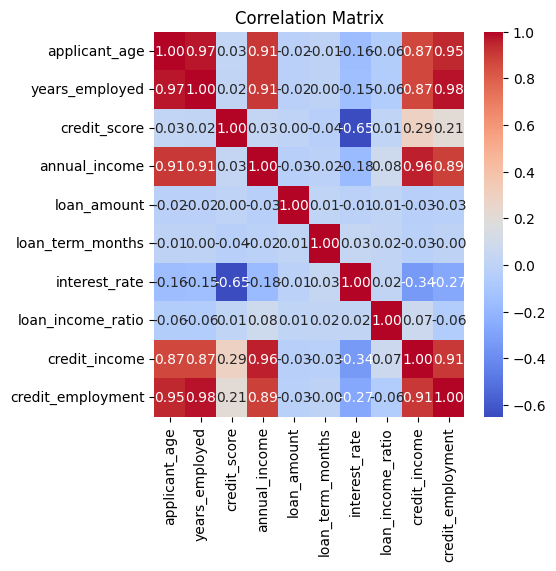

In [1138]:
plt.figure(figsize=(5,5))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'

)

plt.title('Correlation Matrix')
plt.show()

In [1139]:
df

,application_id,applicant_age,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,interest_rate,loan_income_ratio,credit_income,credit_employment
0,APP00001,24,3,Personal,676.0,10000.0,166999,120.0,14.42,16.699900,6760000.0,2028.0
1,APP00002,45,25,Personal,523.0,86595.0,459717,84.0,14.96,5.308817,45289185.0,13075.0
2,APP00003,23,2,Personal,573.0,NaN,355985,36.0,13.18,NaN,NaN,1146.0
3,APP00004,39,17,Education,785.0,98794.0,186615,NaN,10.66,1.888931,77553290.0,13345.0
4,APP00005,43,22,Home,658.0,103832.0,18995,36.0,14.58,0.182940,68321456.0,14476.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,APP01396,50,27,Auto,746.0,127133.0,81237,36.0,9.99,0.638992,94841218.0,20142.0
1396,APP01397,25,5,Business,708.0,38249.0,19014,36.0,14.00,0.497111,27080292.0,3540.0
1397,APP01398,58,37,Auto,573.0,163602.0,308869,24.0,15.45,1.887929,93743946.0,21201.0
1398,APP01399,46,25,Business,649.0,86953.0,477006,120.0,14.19,5.485791,56432497.0,16225.0


In [1140]:
df_clean.drop('applicant_age',inplace=True,axis=1)

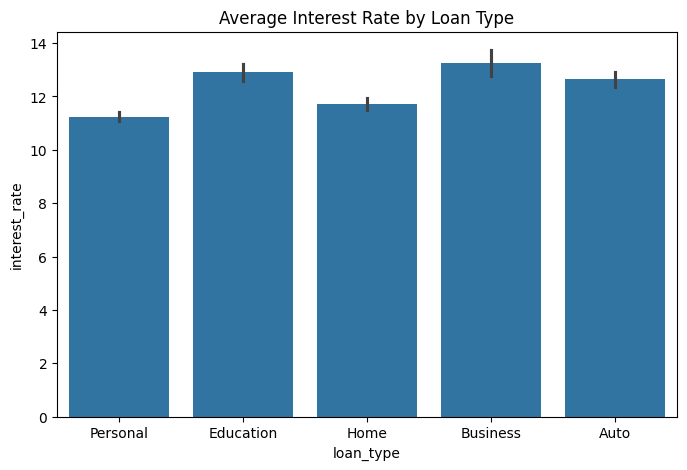

In [1141]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='loan_type',
    y='interest_rate',
    estimator=np.mean
)

plt.title('Average Interest Rate by Loan Type')
# plt.xticks(rotation=45)

plt.show()

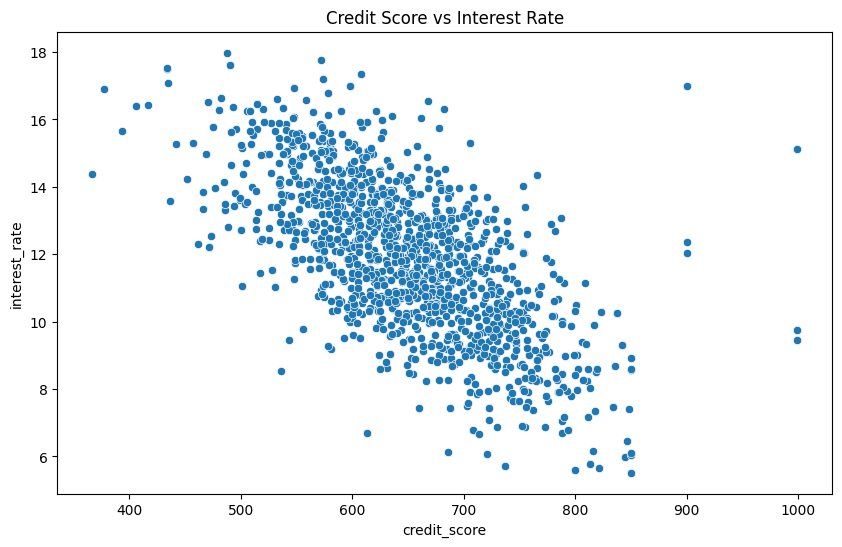

In [1142]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='credit_score',
    y='interest_rate'
)

plt.title('Credit Score vs Interest Rate')

plt.show()

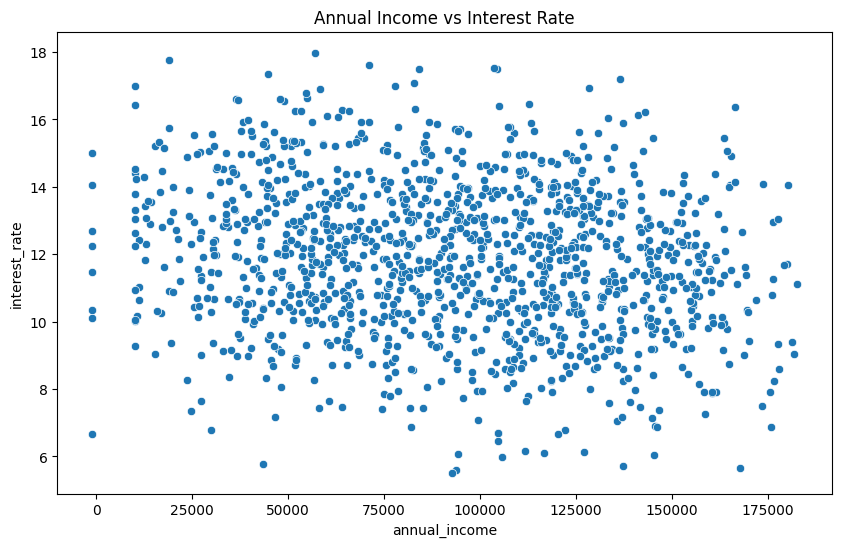

In [1143]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='annual_income',
    y='interest_rate'
)

plt.title('Annual Income vs Interest Rate')

plt.show()

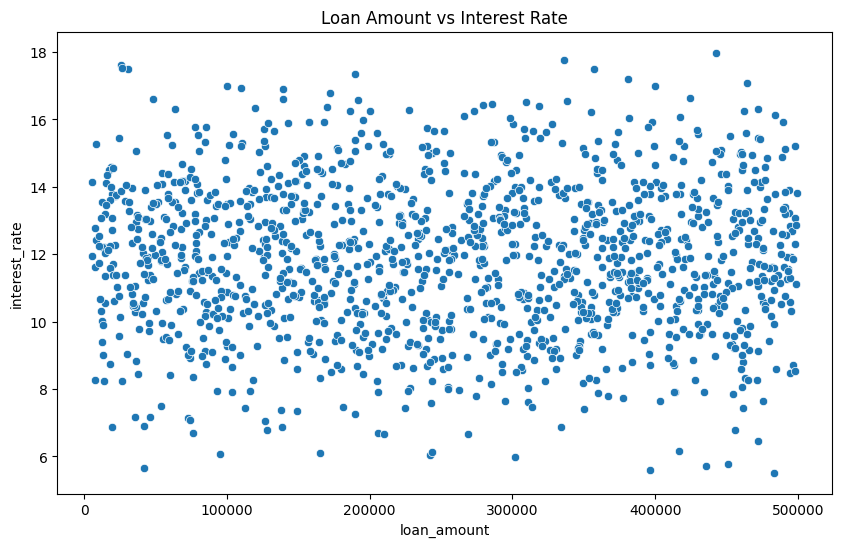

In [1144]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='loan_amount',
    y='interest_rate'
)

plt.title('Loan Amount vs Interest Rate')

plt.show()

### Key Takeaways
Credit score exhibits the strongest relationship with interest rate (-0.57), suggesting that borrowers with stronger credit profiles are generally assigned lower interest rates.

A very strong positive correlation (0.99) exists between applicant_age and years_employed, indicating substantial overlap in the information captured by these variables. While this may introduce multicollinearity in linear models, both features are retained for further model evaluation.

# **4. Feature Engineering**

### Splitting data into features and target variable

In [1145]:
df_clean.shape

(1352, 11)

In [1146]:
df.shape

(1400, 12)

In [1147]:
df.shape

(1400, 12)

In [1148]:
X = df_clean.drop(columns=['interest_rate'])
y = df_clean['interest_rate']

### Splitting data into train test split

In [1149]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [1150]:
X_train.shape

(1081, 10)

In [1151]:
X_train.describe()

,years_employed,credit_score,annual_income,loan_amount,loan_term_months,loan_income_ratio,credit_income,credit_employment
count,1081.000000,1027.000000,1026.000000,1081.000000,1026.000000,1026.000000,9.750000e+02,1027.000000
mean,19.888992,648.956183,92651.592593,254433.277521,54.561404,2.025470,6.007326e+07,12856.722493
std,12.345890,81.080718,41602.158688,142986.921819,33.883655,25.748610,2.855297e+07,8284.923730
min,-5.000000,367.000000,-999.000000,5878.000000,12.000000,-453.929930,-7.412580e+05,-3970.000000
25%,9.000000,598.000000,59001.750000,128961.000000,24.000000,1.311076,3.755260e+07,5652.000000
50%,20.000000,648.000000,93488.000000,253018.000000,48.000000,2.731501,5.932931e+07,12873.000000
75%,31.000000,701.000000,124553.250000,378761.000000,84.000000,4.496145,8.229657e+07,19670.000000
max,40.000000,999.000000,182507.000000,499335.000000,120.000000,45.731883,1.377981e+08,32000.000000


In [1152]:
X_train['loan_type'].value_counts()

,count
loan_type,
Personal,441
Home,312
Auto,158
Education,111
Business,59


To prevent data leakage and ensure reproducibility, all preprocessing steps are incorporated into a machine learning pipeline.

The preprocessing workflow includes:

- Median imputation for numerical features
- Most frequent imputation for categorical features
- Standardization of numerical variables
- One-hot encoding of categorical variables

In [1153]:
X_train

,application_id,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,loan_income_ratio,credit_income,credit_employment
999,APP01000,16,Education,755.0,55470.0,290337,84.0,5.234127,41879850.0,12080.0
963,APP00964,40,Personal,595.0,-999.0,284732,36.0,-285.017017,-594405.0,23800.0
110,APP00111,23,Personal,689.0,107754.0,55465,48.0,0.514737,74242506.0,15847.0
733,APP00734,22,Business,NaN,95479.0,362606,60.0,3.797757,NaN,NaN
1246,APP01247,40,Auto,564.0,146838.0,352025,84.0,2.397370,82816632.0,22560.0
...,...,...,...,...,...,...,...,...,...,...
1137,APP01138,16,Personal,688.0,58058.0,225067,84.0,3.876589,39943904.0,11008.0
1174,APP01175,8,Home,611.0,60448.0,416463,36.0,6.889608,36933728.0,4888.0
1342,APP01343,10,Auto,629.0,54803.0,213455,84.0,3.894951,34471087.0,6290.0
886,APP00887,33,Auto,725.0,150211.0,187034,12.0,1.245142,108902975.0,23925.0


In [1154]:
numerical_features = [
    'years_employed',

    'credit_score',
    'annual_income',
    'loan_amount',
    'loan_term_months',
    'loan_income_ratio',
    'credit_income',
    'credit_employment'
]

categorical_features = [
    'loan_type'
]

In [1155]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1081 entries, 999 to 1170
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   application_id     1081 non-null   object 
 1   years_employed     1081 non-null   int64  
 2   loan_type          1081 non-null   object 
 3   credit_score       1027 non-null   float64
 4   annual_income      1026 non-null   float64
 5   loan_amount        1081 non-null   int64  
 6   loan_term_months   1026 non-null   float64
 7   loan_income_ratio  1026 non-null   float64
 8   credit_income      975 non-null    float64
 9   credit_employment  1027 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 92.9+ KB


In [1156]:
X_train

,application_id,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,loan_income_ratio,credit_income,credit_employment
999,APP01000,16,Education,755.0,55470.0,290337,84.0,5.234127,41879850.0,12080.0
963,APP00964,40,Personal,595.0,-999.0,284732,36.0,-285.017017,-594405.0,23800.0
110,APP00111,23,Personal,689.0,107754.0,55465,48.0,0.514737,74242506.0,15847.0
733,APP00734,22,Business,NaN,95479.0,362606,60.0,3.797757,NaN,NaN
1246,APP01247,40,Auto,564.0,146838.0,352025,84.0,2.397370,82816632.0,22560.0
...,...,...,...,...,...,...,...,...,...,...
1137,APP01138,16,Personal,688.0,58058.0,225067,84.0,3.876589,39943904.0,11008.0
1174,APP01175,8,Home,611.0,60448.0,416463,36.0,6.889608,36933728.0,4888.0
1342,APP01343,10,Auto,629.0,54803.0,213455,84.0,3.894951,34471087.0,6290.0
886,APP00887,33,Auto,725.0,150211.0,187034,12.0,1.245142,108902975.0,23925.0


In [1157]:
X_train

,application_id,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,loan_income_ratio,credit_income,credit_employment
999,APP01000,16,Education,755.0,55470.0,290337,84.0,5.234127,41879850.0,12080.0
963,APP00964,40,Personal,595.0,-999.0,284732,36.0,-285.017017,-594405.0,23800.0
110,APP00111,23,Personal,689.0,107754.0,55465,48.0,0.514737,74242506.0,15847.0
733,APP00734,22,Business,NaN,95479.0,362606,60.0,3.797757,NaN,NaN
1246,APP01247,40,Auto,564.0,146838.0,352025,84.0,2.397370,82816632.0,22560.0
...,...,...,...,...,...,...,...,...,...,...
1137,APP01138,16,Personal,688.0,58058.0,225067,84.0,3.876589,39943904.0,11008.0
1174,APP01175,8,Home,611.0,60448.0,416463,36.0,6.889608,36933728.0,4888.0
1342,APP01343,10,Auto,629.0,54803.0,213455,84.0,3.894951,34471087.0,6290.0
886,APP00887,33,Auto,725.0,150211.0,187034,12.0,1.245142,108902975.0,23925.0


In [1158]:
imputer = SimpleImputer(strategy='median')

X_train[numerical_features] = imputer.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = imputer.transform(
    X_test[numerical_features]
)

In [1159]:
X_train.isnull().sum()

,0
application_id,0
years_employed,0
loan_type,0
credit_score,0
annual_income,0
loan_amount,0
loan_term_months,0
loan_income_ratio,0
credit_income,0
credit_employment,0


In [1160]:
# df['years_employed']=imputer.fit_transform(df['years_employed'])

In [1161]:
X_train.shape, X_test.shape

((1081, 10), (271, 10))

In [1162]:
y_train.shape, y_test.shape

((1081,), (271,))

In [1163]:
preprocessor = ColumnTransformer(
    transformers=[
        ( 'num', StandardScaler(),numerical_features),
        ('cat',OneHotEncoder(handle_unknown='ignore',drop='first'),categorical_features)
    ],
    remainder='drop'
)

In [1164]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [1165]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(1081, 12)
(271, 12)


In [1166]:
X_train_processed

array([[-0.31514874,  1.34307725, -0.91887269, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.62971782, -0.68245914, -2.31280176, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.252104  ,  0.50754349,  0.37175026, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.80136538, -0.25203266, -0.93533749, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.06246507,  0.96328918,  1.41979514, ...,  0.        ,
         0.        ,  0.        ],
       [-1.20654592,  0.31764945, -1.32871534, ...,  0.        ,
         0.        ,  1.        ]])

# **Model Development**

 ## Linear Regression Model

Linear Regression is used as the baseline model for predicting loan interest rates. The model provides a simple and interpretable benchmark against which more advanced models can be compared.

In [1167]:
# # lr = LinearRegression()
# from xgboost import XGBRegressor
# lr=XGBRegressor()
# lr.fit(
#     X_train_processed,
#     y_train
# )

In [1168]:
X_test

,application_id,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,loan_income_ratio,credit_income,credit_employment
50,APP00051,33.0,Personal,572.0,135973.0,420036.0,48.0,3.089113,77776556.0,18876.0
653,APP00654,29.0,Home,581.0,118749.0,161238.0,36.0,1.357805,68993169.0,16849.0
1071,APP01072,28.0,Home,506.0,136476.0,61686.0,12.0,0.451992,69056856.0,14168.0
766,APP00767,31.0,Personal,612.0,124594.0,5916.0,48.0,0.047482,76251528.0,18972.0
948,APP00949,30.0,Personal,758.0,139139.0,310821.0,24.0,2.233888,105467362.0,22740.0
...,...,...,...,...,...,...,...,...,...,...
751,APP00752,20.0,Personal,999.0,80249.0,459661.0,48.0,5.727934,80168751.0,19980.0
1330,APP01331,27.0,Personal,536.0,102794.0,497827.0,48.0,4.842958,55097584.0,14472.0
1353,APP01354,30.0,Auto,684.0,124635.0,89567.0,24.0,0.718634,85250340.0,20520.0
744,APP00745,40.0,Home,559.0,173537.0,54514.0,36.0,0.314135,97007183.0,22360.0


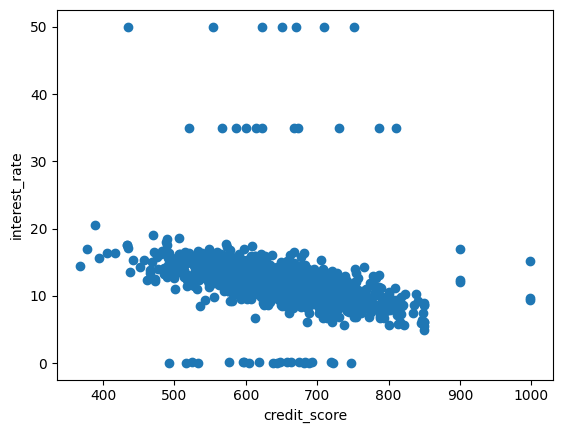

In [1169]:
import matplotlib.pyplot as plt

plt.scatter(df['credit_score'], df['interest_rate'])
plt.xlabel('credit_score')
plt.ylabel('interest_rate')
plt.show()

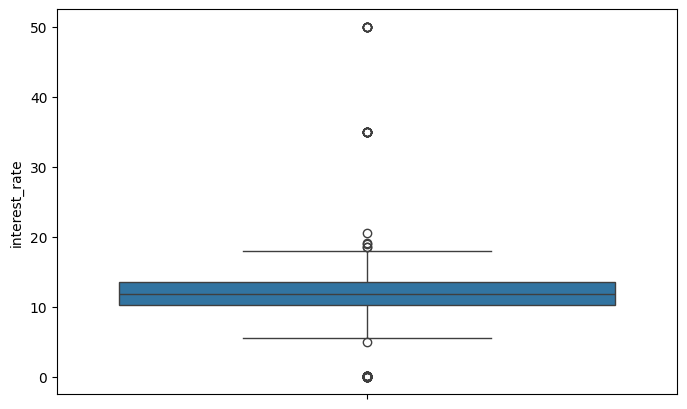

In [1170]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df['interest_rate'])
plt.show()

In [1171]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
1          num__credit_score    0.453609
3           num__loan_amount    0.087734
6         num__credit_income    0.079566
2         num__annual_income    0.079340
5     num__loan_income_ratio    0.078195
7     num__credit_employment    0.062188
0        num__years_employed    0.042619
4      num__loan_term_months    0.041796
11   cat__loan_type_Personal    0.033208
8    cat__loan_type_Business    0.016682
9   cat__loan_type_Education    0.015250
10       cat__loan_type_Home    0.009813


In [1172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "linearRegression": LinearRegression(),
    "SVR": SVR(),
    "MLP": MLPRegressor(random_state=42, max_iter=1000)
}

results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    preds = model.predict(X_test_processed)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)

    results.append([name, r2, mae, rmse])

for row in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{row[0]:15} | R²={row[1]:.4f} | MAE={row[2]:.4f} | RMSE={row[3]:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1586
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 12
[LightGBM] [Info] Start training from score 11.868196
SVR             | R²=0.4612 | MAE=1.2547 | RMSE=1.5863
linearRegression | R²=0.4543 | MAE=1.2675 | RMSE=1.5965
MLP             | R²=0.4158 | MAE=1.2904 | RMSE=1.6518
Random Forest   | R²=0.3773 | MAE=1.3526 | RMSE=1.7054
LightGBM        | R²=0.3643 | MAE=1.3816 | RMSE=1.7231
XGBoost         | R²=0.3119 | MAE=1.4304 | RMSE=1.7928


In [1173]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'epsilon': [0.01, 0.1, 0.5]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Params: {'C': 100, 'epsilon': 0.5, 'gamma': 0.001}
Best CV R2: 0.4976151632274991
